# Skull Fracture Anchor Analysis

Estimate representative anchor sizes from fracture bounding boxes.

## 1. Setup

Define paths and clustering settings.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans

In [2]:
METADATA_PATH = Path("../data/train/annotated.csv")
ANNOTATIONS_DIR = Path("../data/train/annotations")

N_ANCHORS = 5
SEED = 2026

FRACTURE_COLUMN = "fracture_prob"
PATH_COLUMN = "relative_path"

## 2. Load Metadata

Keep only fracture-positive slices.

In [3]:
metadata = pd.read_csv(METADATA_PATH)

fracture_slices = metadata[metadata[FRACTURE_COLUMN].fillna(0).astype(bool)]

print(f"Total slices: {len(metadata):,}")
print(f"Fracture-positive slices: {len(fracture_slices):,}")

fracture_slices.head()

Total slices: 4,959
Fracture-positive slices: 260


,series_id,patient_id,slice_id,pixel_spacing_y,pixel_spacing_x,slice_thickness,relative_path,IntraventricularHemorrhage,IntraparenchymalHemorrhage,SubduralHemorrhage,EpiduralHemorrhage,SubarachnoidHemorrhage,IntraventricularHemorrhage_Area,IntraparenchymalHemorrhage_Area,SubduralHemorrhage_Area,EpiduralHemorrhage_Area,SubarachnoidHemorrhage_Area,fracture_prob,MLS_mm,triage_class
7,2265,765202,1.2.392.200036.9116.2.6.1.48.1211476691.145931...,0.468,0.468,8.0,2265/1.2.392.200036.9116.2.6.1.48.1211476691.1...,False,False,False,False,False,0.0,0.0,0.0,0.0,0.0,1.0,6.125305,2
8,2265,765202,1.2.392.200036.9116.2.6.1.48.1211476691.145931...,0.468,0.468,8.0,2265/1.2.392.200036.9116.2.6.1.48.1211476691.1...,True,False,False,False,False,174.0,0.0,0.0,0.0,0.0,1.0,3.510152,2
9,2265,765202,1.2.392.200036.9116.2.6.1.48.1211476691.145931...,0.468,0.468,8.0,2265/1.2.392.200036.9116.2.6.1.48.1211476691.1...,False,False,False,False,False,0.0,0.0,0.0,0.0,0.0,1.0,5.423461,2
10,2265,765202,1.2.392.200036.9116.2.6.1.48.1211476691.145931...,0.468,0.468,8.0,2265/1.2.392.200036.9116.2.6.1.48.1211476691.1...,False,False,False,False,False,0.0,0.0,0.0,0.0,0.0,1.0,6.589459,2
11,2265,765202,1.2.392.200036.9116.2.6.1.48.1211476691.145931...,0.468,0.468,8.0,2265/1.2.392.200036.9116.2.6.1.48.1211476691.1...,False,False,False,False,False,0.0,0.0,0.0,0.0,0.0,1.0,1.974038,2


## 3. Extract Bounding Boxes

Read fracture annotations and collect valid box sizes.

In [4]:
def find_annotation(relative_path: str) -> Path | None:
    path = ANNOTATIONS_DIR / relative_path

    if path.is_file():
        return path

    path = path.with_suffix(".json")
    return path if path.is_file() else None


records = []

In [5]:
for relative_path in fracture_slices[PATH_COLUMN].dropna():
    path = find_annotation(f"{relative_path}.json")

    if path is None:
        continue

    annotation = json.loads(path.read_text())

    for _, _, width, height in annotation.get("boxes_xywh", []):
        if width > 0 and height > 0:
            records.append([width, height])

boxes = pd.DataFrame(records, columns=["height_px", "width_px"])

if boxes.empty:
    raise ValueError("No fracture bounding boxes found.")

boxes["aspect_ratio"] = boxes["width_px"] / boxes["height_px"]

print(f"Extracted boxes: {len(boxes):,}")

boxes.head()

Extracted boxes: 356


,height_px,width_px,aspect_ratio
0,41,54,1.317073
1,55,68,1.236364
2,42,54,1.285714
3,61,68,1.114754
4,39,33,0.846154


## 4. Aspect Ratios

Values near `1` represent roughly square boxes.

In [6]:
boxes["aspect_ratio"].quantile([0.10, 0.25, 0.50, 0.75, 0.90]).to_frame("aspect_ratio")

,aspect_ratio
0.10,0.695776
0.25,0.846154
0.50,1.000000
0.75,1.233333
0.90,1.470588


## 5. Estimate Anchors

Cluster box widths and heights with K-Means.

In [7]:
kmeans = KMeans(
    n_clusters=N_ANCHORS,
    random_state=SEED,
    n_init=10,
)

kmeans.fit(boxes[["width_px", "height_px"]])

anchors = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=["width_px", "height_px"],
)

anchors["aspect_ratio"] = anchors["width_px"] / anchors["height_px"]
anchors["area_px2"] = anchors["width_px"] * anchors["height_px"]

anchors = anchors.sort_values("area_px2").reset_index(drop=True)
anchors.index += 1
anchors.index.name = "anchor"

anchors.round(2)

,width_px,height_px,aspect_ratio,area_px2
anchor,,,,
1,37.82,38.02,0.99,1438.15
2,67.68,68.06,0.99,4605.89
3,178.62,139.31,1.28,24882.50
4,189.75,345.25,0.55,65511.19
5,411.00,181.22,2.27,74482.33


## 6. Visualization

Compare observed box sizes with the learned anchors.

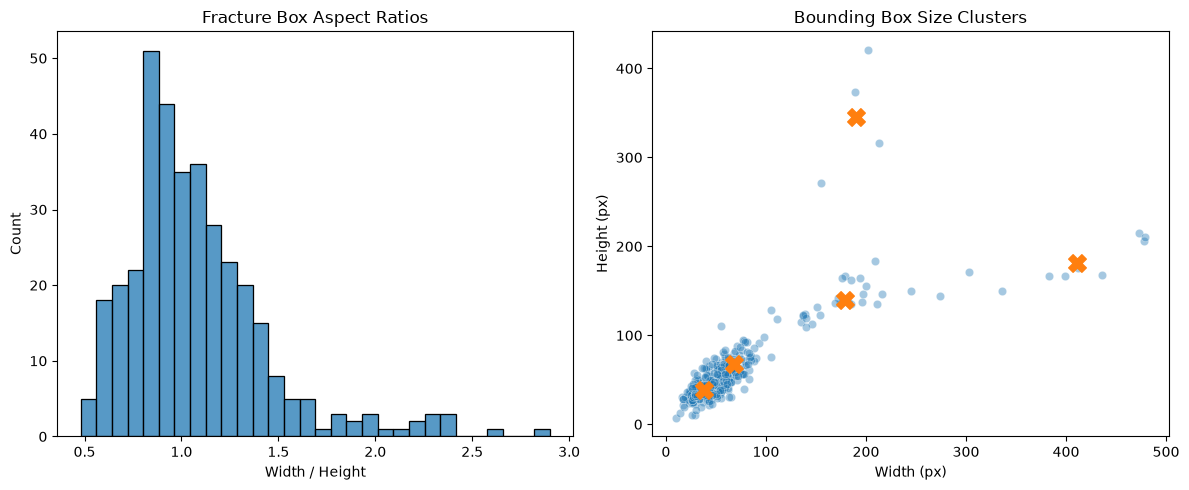

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(
    data=boxes,
    x="aspect_ratio",
    bins=30,
    ax=axes[0],
)
axes[0].set_title("Fracture Box Aspect Ratios")
axes[0].set_xlabel("Width / Height")

sns.scatterplot(
    data=boxes,
    x="width_px",
    y="height_px",
    alpha=0.4,
    ax=axes[1],
)

axes[1].scatter(
    anchors["width_px"],
    anchors["height_px"],
    marker="X",
    s=160,
)

axes[1].set_title("Bounding Box Size Clusters")
axes[1].set_xlabel("Width (px)")
axes[1].set_ylabel("Height (px)")

plt.tight_layout()
plt.show()